In [3]:
import math
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


print("A conectar ao IBM Quantum...")
service = QiskitRuntimeService(
    channel="ibm_quantum_platform", 
    token="T6OsaAPtc7yxM_j_Ntl33jmipr3MqAEky0eMz4h1sE2D" 
   
)

nome_backend = "ibm_fez"
backend = service.backend(nome_backend)
print(f"✅ Conectado com sucesso ao backend: {backend.name}")

qiskit_runtime_service._discover_account:WARNING:2026-05-11 09:48:25,724: Loading account with the given token. A saved account will not be used.


A conectar ao IBM Quantum...


qiskit_runtime_service.__init__:WARNING:2026-05-11 09:48:30,932: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-11 09:48:30,935: Using instance: open-instance, plan: open


✅ Conectado com sucesso ao backend: ibm_fez


In [4]:
def criar_circuito_shor_para_N(N):
    a = 2
    while math.gcd(a, N) != 1:
        a += 1
        
    
    L = math.ceil(math.log2(N)) 
    m = 2 * L                   
    
    
    def criar_operador_amodN(a, power):
        U = np.zeros((2**L, 2**L))
        for i in range(2**L):
            if i < N:
                novo_estado = (i * (a**power)) % N
                U[novo_estado, i] = 1
            else:
                U[i, i] = 1 
        return UnitaryGate(U, label=f"U^{2**power}")
        
    
    q_up = QuantumRegister(m, name="contagem")
    q_down = QuantumRegister(L, name="trabalho")
    c = ClassicalRegiste# Gráfico 2: Barra de Eficiência
    qc.x(q_down[0])
    
   
    for q in range(m):
        op_u = # Gráfico 2: Barra de Eficiênciacriar_operador_amodN(a, 2**q)
        qc.append(op_u.control(1), [q_up[q]] + q_down[:])
        
   
    qc.append(QFT(m, inverse=True).to_gate(), q_up)
    

    qc.measure(q_up, c)
    # Gráfico 2: Barra de Eficiência
    return qc, a, L, m

In [5]:
valores_N = [15, 21, 33, 35,55] 
resultados_experimento = {}


pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
sampler = Sampler(mode=backend)

print(f"🚀 A iniciar submissão em lote para os semi-primos N = {valores_N}...")

for N in valores_N:
    print(f"\n--- A processar N = {N} ---")
    
    try:
       
        qc, a_usado, L, m = criar_circuito_shor_para_N(N)
        print(f"   [+] Parâmetros: a={a_usado}, Total Qubits={L+m}")
        
       
        inicio_transp = time.time()
        qc_transpilado = pm.run(qc)
        tempo_transp = time.time() - inicio_transp
        
        
        profundidade = qc_transpilado.depth()
        cnots = qc_transpilado.num_nonlocal_gates()
        print(f"   [+] Transpilação: {tempo_transp:.1f}s | Profundidade: {profundidade} | CNOTs: {cnots}")
        
        # 4. Submeter o Job
        job = sampler.run([qc_transpilado], shots=1024)
        job_id = job.job_id()
        print(f"   [+] Job submetido! ID: {job_id}")
        
        # Guardar dados
        resultados_experimento[N] = {
            "job_id": job_id,
            "a_usado": a_usado,
            "qubits_logicos": L+m,
            "profundidade": profundidade,
            "cnots": cnots,
            "tempo_compilacao_seg": tempo_transp,
            "status": "submetido"
        }
        
    except Exception as e:
        print(f"   [!] ERRO ao processar N={N}: {e}")
        resultados_experimento[N] = {"erro": str(e)}

🚀 A iniciar submissão em lote para os semi-primos N = [15, 21, 33, 35, 55]...

--- A processar N = 15 ---


/tmp/ipykernel_12807/3790962058.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(m, inverse=True).to_gate(), q_up)


   [+] Parâmetros: a=2, Total Qubits=12
   [+] Transpilação: 0.2s | Profundidade: 2814 | CNOTs: 905
   [+] Job submetido! ID: d80tsgntjchs73bm50d0

--- A processar N = 21 ---
   [+] Parâmetros: a=2, Total Qubits=15
   [+] Transpilação: 2.4s | Profundidade: 68064 | CNOTs: 19653
   [+] Job submetido! ID: d80tsknoha1c73bjl1n0

--- A processar N = 33 ---
   [+] Parâmetros: a=2, Total Qubits=18
   [+] Transpilação: 12.9s | Profundidade: 336406 | CNOTs: 96623
   [+] Job submetido! ID: d80tt67tjchs73bm5170

--- A processar N = 35 ---
   [+] Parâmetros: a=2, Total Qubits=18
   [+] Transpilação: 13.3s | Profundidade: 339388 | CNOTs: 97682
   [+] Job submetido! ID: d80ttng0bvlc73d0bge0

--- A processar N = 55 ---
   [+] Parâmetros: a=2, Total Qubits=18
   [+] Transpilação: 12.7s | Profundidade: 336026 | CNOTs: 96643
   [+] Job submetido! ID: d80tubvtjchs73bm52o0


In [6]:
nome_arquivo = f"dados_semiprimos_shor_{backend.name}.json"

with open(nome_arquivo, "w") as f:
    json.dump(resultados_experimento, f, indent=4)

print(f"✅ Todos os IDs e métricas de profundidade foram guardados no ficheiro '{nome_arquivo}'!")
print("Pode fechar o Jupyter. Voltaremos mais tarde para resgatar os resultados com a Célula 5.")

✅ Todos os IDs e métricas de profundidade foram guardados no ficheiro 'dados_semiprimos_shor_ibm_fez.json'!
Pode fechar o Jupyter. Voltaremos mais tarde para resgatar os resultados com a Célula 5.


In [7]:
nome_arquivo = f"dados_semiprimos_shor_{backend.name}.json"

with open(nome_arquivo, "r") as f:
    resultados_experimento = json.load(f)

print("A verificar o status dos jobs na IBM e a transferir resultados...")

for str_N, dados in resultados_experimento.items():
    if "job_id" in dados and dados.get("status") != "concluido":
        job_id = dados["job_id"]
        print(f"[{str_N}] A verificar Job {job_id}...")
        
        try:
            job = service.job(job_id)
            status = job.status() 
            if status == 'DONE':
                resultado = job.result()
                
                pub_result = resultado[0]
                contagens = pub_result.data.medicao.get_counts()
                
                resultados_experimento[str_N]["counts"] = contagens
                resultados_experimento[str_N]["status"] = "concluido"
                print(f"  -> Resultados transferidos com sucesso!")
            else:
              
                print(f"  -> O Job ainda está {status}. Tente novamente mais tarde.")
                
        except Exception as e:
            print(f"  -> Erro ao resgatar job: {e}")

with open(nome_arquivo, "w") as f:
    json.dump(resultados_experimento, f, indent=4)

A verificar o status dos jobs na IBM e a transferir resultados...
[15] A verificar Job d80tsgntjchs73bm50d0...
  -> Resultados transferidos com sucesso!
[21] A verificar Job d80tsknoha1c73bjl1n0...
  -> Resultados transferidos com sucesso!
[33] A verificar Job d80tt67tjchs73bm5170...
  -> Resultados transferidos com sucesso!
[35] A verificar Job d80ttng0bvlc73d0bge0...
  -> Resultados transferidos com sucesso!
[55] A verificar Job d80tubvtjchs73bm52o0...
  -> Resultados transferidos com sucesso!


N=15 | a=2 | r_ideal=04 | Acertos: 0474 | Erros: 0550 | Sucesso: 46.3%
N=21 | a=2 | r_ideal=06 | Acertos: 0083 | Erros: 0941 | Sucesso: 8.1%
N=33 | a=2 | r_ideal=10 | Acertos: 0050 | Erros: 0974 | Sucesso: 4.9%
N=35 | a=2 | r_ideal=12 | Acertos: 0081 | Erros: 0943 | Sucesso: 7.9%
N=55 | a=2 | r_ideal=20 | Acertos: 0049 | Erros: 0975 | Sucesso: 4.8%


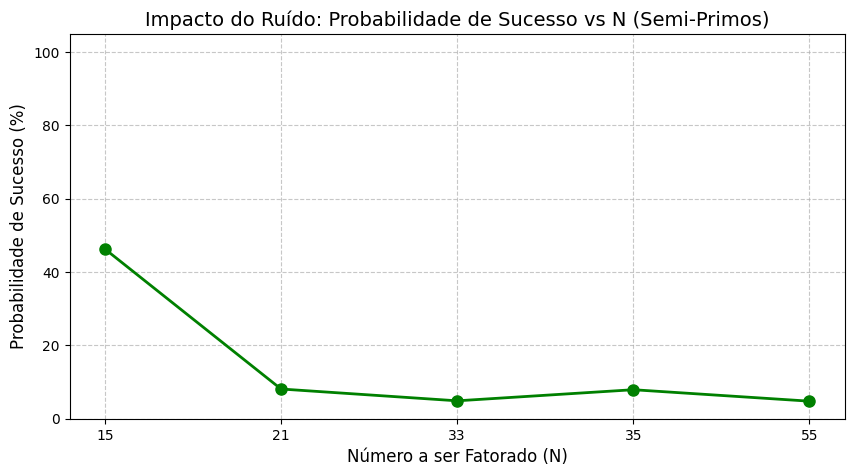

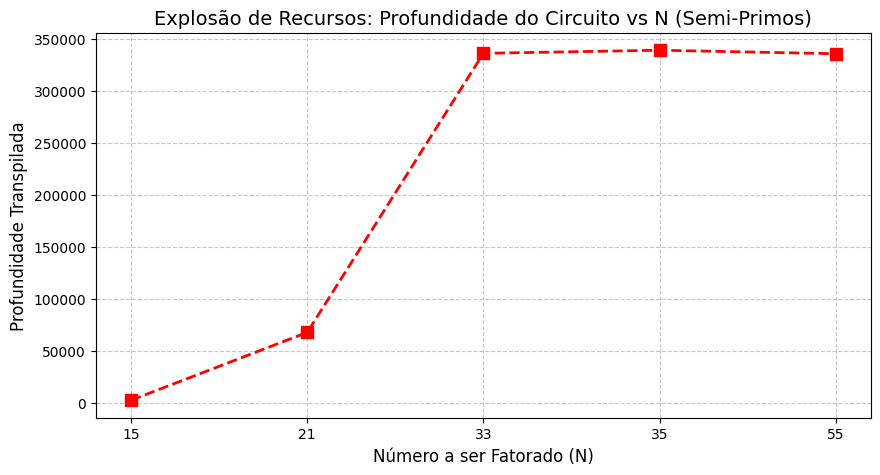

In [8]:
def calcular_r_esperado(a, N):
    r = 1
    while (a**r) % N != 1:
        r += 1
    return r

lista_N = []
lista_prob_sucesso = []
lista_profundidade = []

for str_N, dados in resultados_experimento.items():
    if dados.get("status") == "concluido" and "counts" in dados:
        N = int(str_N)
        a = dados["a_usado"]
        counts = dados["counts"]
        L = math.ceil(math.log2(N
￼
))
        m = dados["qubits_logicos"] - L 
        
        r_esperado = calcular_r_esperado(a, N)
        total_shots = sum(counts.values())
        sucessos = 0
        erros = 0
        
        for estado_binario, freq in counts.items():
            fase = int(estado_binario, 2) / (2**m)
            r_est = Fraction(fase).limit_denominator(N).denominator
            
            if r_est > 1 and r_esperado % r_est == 0:
                sucessos += freq
            else:
                erros += freq
                
        prob_sucesso = (sucessos / total_shots) * 100
        
        lista_N.append(str(N)) # Transformado em string para o eixo X ficar bonito e sem falhas
        lista_prob_sucesso.append(prob_sucesso)
        lista_profundidade.append(dados["profundidade"])
        
        print(f"N={N:02d} | a={a} | r_ideal={r_esperado:02d} | Acertos: {sucessos:04d} | Erros: {erros:04d} | Sucesso: {prob_sucesso:.1f}%")

# GRÁFICO 1: Taxa de Acertos vs N
plt.figure(figsize=(10, 5))
plt.plot(lista_N, lista_prob_sucesso, marker='o', linestyle='-', color='green', linewidth=2, markersize=8)
plt.title('Impacto do Ruído: Probabilidade de Sucesso vs N (Semi-Primos)', fontsize=14)
plt.xlabel('Número a ser Fatorado (N)', fontsize=12)
plt.ylabel('Probabilidade de Sucesso (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 105)
plt.show()

# GRÁFICO 2: Profundidade do Circuito vs N
plt.figure(figsize=(10, 5))
plt.plot(lista_N, lista_profundidade, marker='s', linestyle='--', color='red', linewidth=2, markersize=8)
plt.title('Explosão de Recursos: Profundidade do Circuito vs N (Semi-Primos)', fontsize=14)
plt.xlabel('Número a ser Fatorado (N)', fontsize=12)
plt.ylabel('Profundidade Transpilada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np
import math
from fractions import Fraction


valores_N = [15, 21, 33, 35, 55]


lista_N_str = []
lista_sucesso_pennylane = []


def calcular_r_esperado(a, N):
    r = 1
    while (a**r) % N != 1:
        r += 1
    return r

print("🚀 A iniciar simulação matemática ideal (PennyLane) para todos os N...")

for N in valores_N:
    print(f"\n--- A simular teoria para N = {N} ---")
    
    
    qc_qiskit, a_usado, L, m = criar_circuito_shor_para_N(N)
    total_qubits = L + m
    
    qc_qiskit.remove_final_measurements()
    
    
    dev = qml.device("default.qubit", wires=total_qubits)
    
   
    @qml.qnode(dev)
    def circuito_ideal():
        qml.from_qiskit(qc_qiskit)()
        
        return qml.probs(wires=range(m))

    probabilidades = circuito_ideal()
    
   
    r_esperado = calcular_r_esperado(a_usado, N)
    sucesso_ideal = 0.0
    
    for i, prob in enumerate(probabilidades):
        if prob > 1e-5: 
            
            
            bin_str = format(i, f'0{m}b')           
            bin_str_invertido = bin_str[::-1]       
            valor_real = int(bin_str_invertido, 2) 
            
            
            fase = valor_real / (2**m)
            r_est = Fraction(fase).limit_denominator(N).denominator

🚀 A iniciar simulação matemática ideal (PennyLane) para todos os N...

--- A simular teoria para N = 15 ---


/tmp/ipykernel_12807/3790962058.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(m, inverse=True).to_gate(), q_up)
/home/luis/cwq/coding-with-qiskit/cwq/coding-with-qiskit/envs/tcc_novo_limpo/lib/python3.11/site-packages/pennylane_qiskit/converter.py:585: UserWarning: pennylane_qiskit.converter: The ControlledGate instruction is not supported by PennyLane, and has not been added to the template.
  warnings.warn(
/home/luis/cwq/coding-with-qiskit/cwq/coding-with-qiskit/envs/tcc_novo_limpo/lib/python3.11/site-packages/pennylane_qiskit/converter.py:585: UserWarning: pennylane_qiskit.converter: The Gate instruction is not supported by PennyLane, and has not been added to the template.
  warnings.warn(



--- A simular teoria para N = 21 ---


/tmp/ipykernel_12807/3790962058.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(m, inverse=True).to_gate(), q_up)



--- A simular teoria para N = 33 ---

--- A simular teoria para N = 35 ---

--- A simular teoria para N = 55 ---


✅ Arquivo 'dados_semiprimos_shor_ibm_fez.json' carregado com sucesso!
🎨 A gerar gráficos alinhados...


/tmp/ipykernel_12807/3790962058.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(m, inverse=True).to_gate(), q_up)


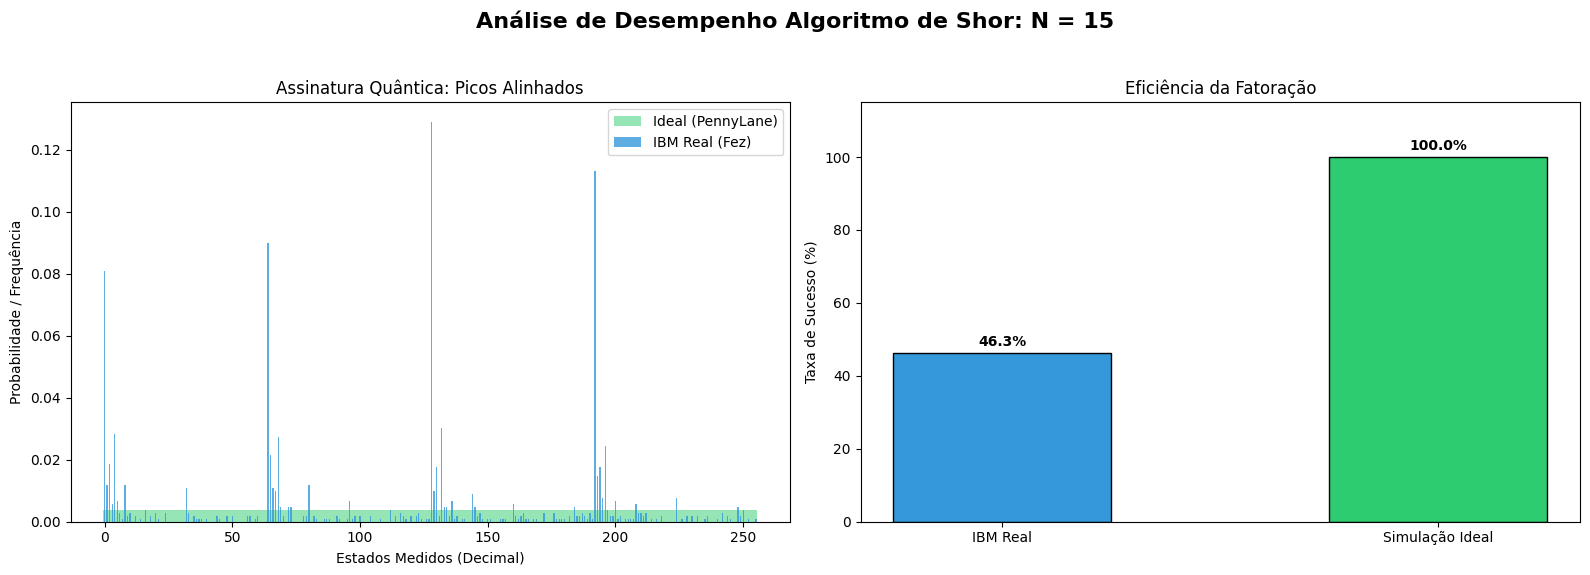

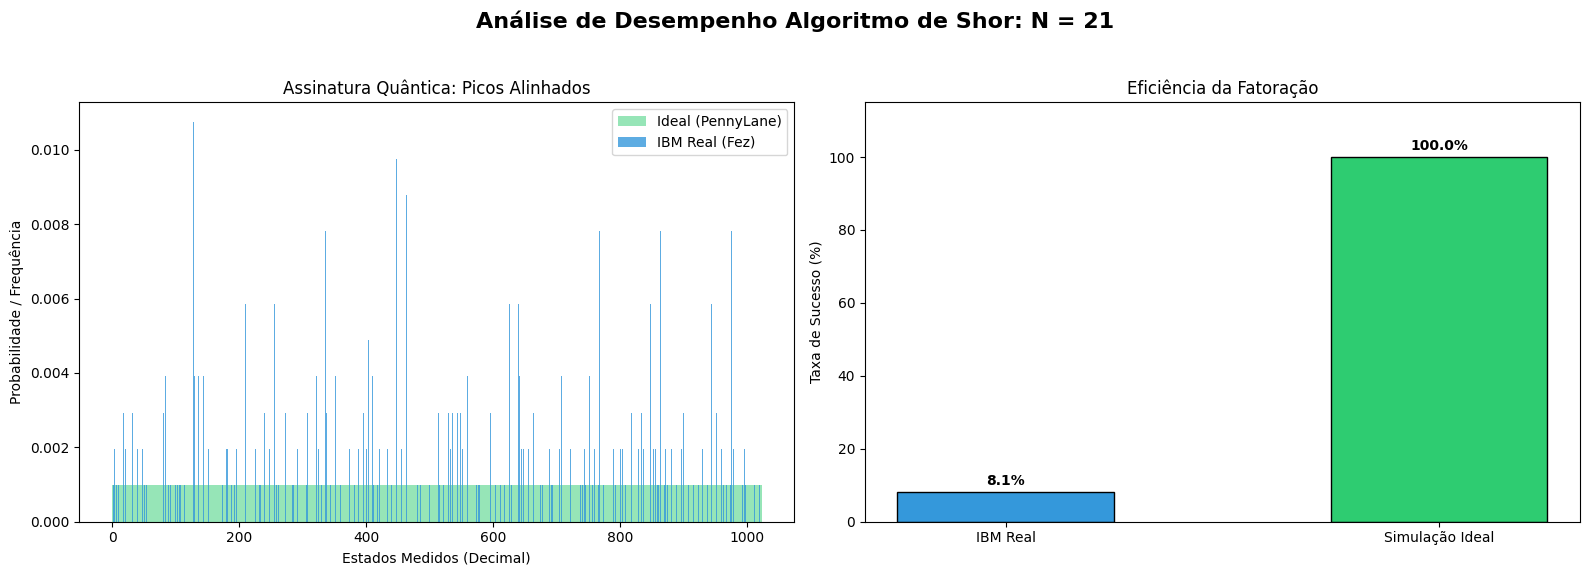

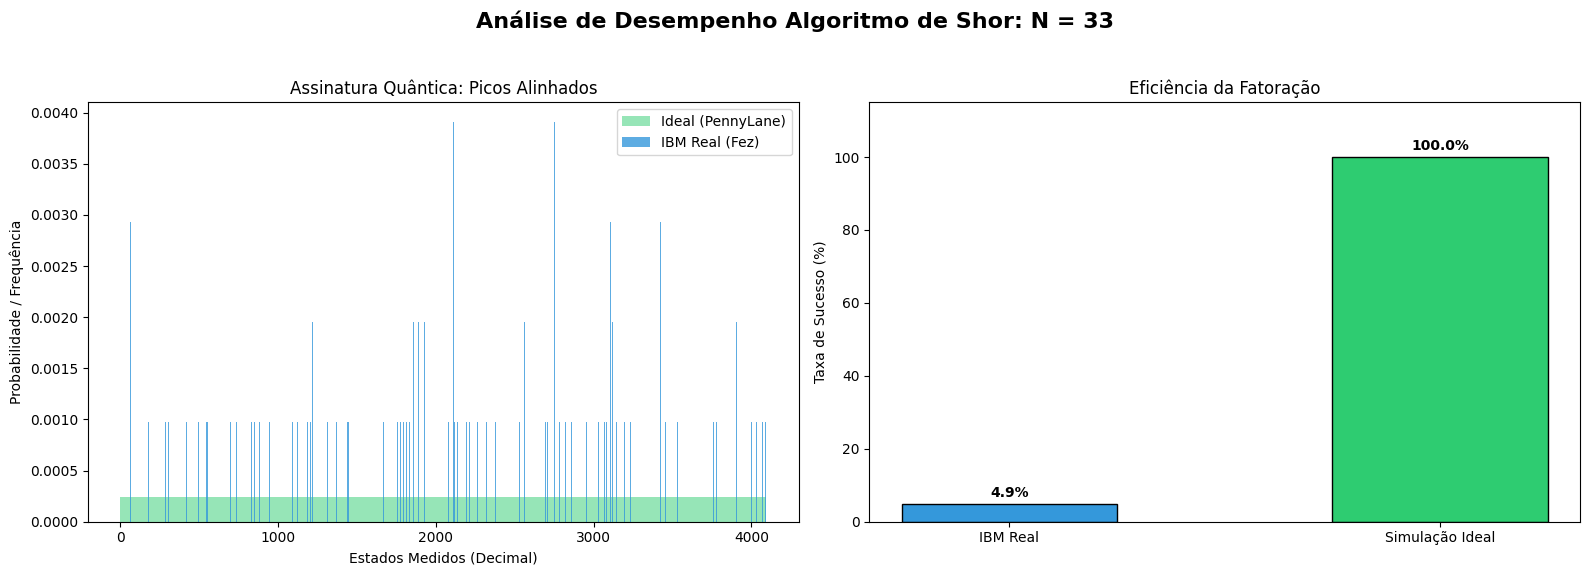

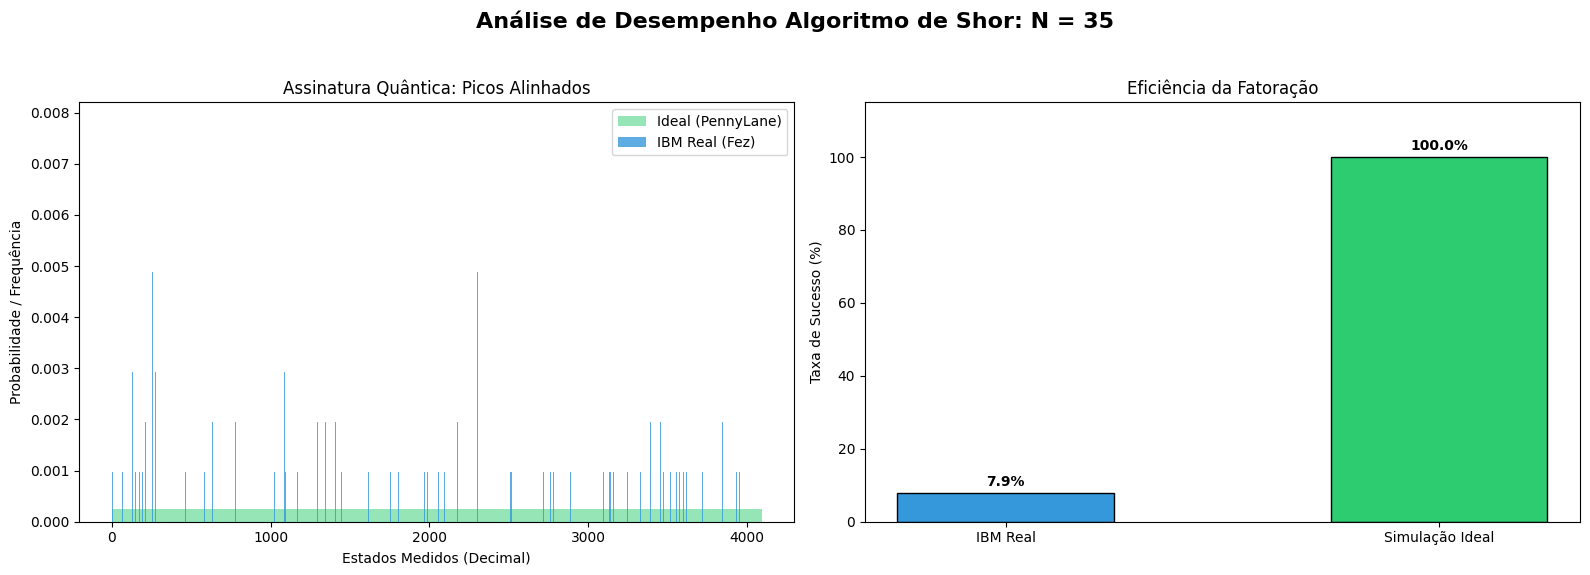

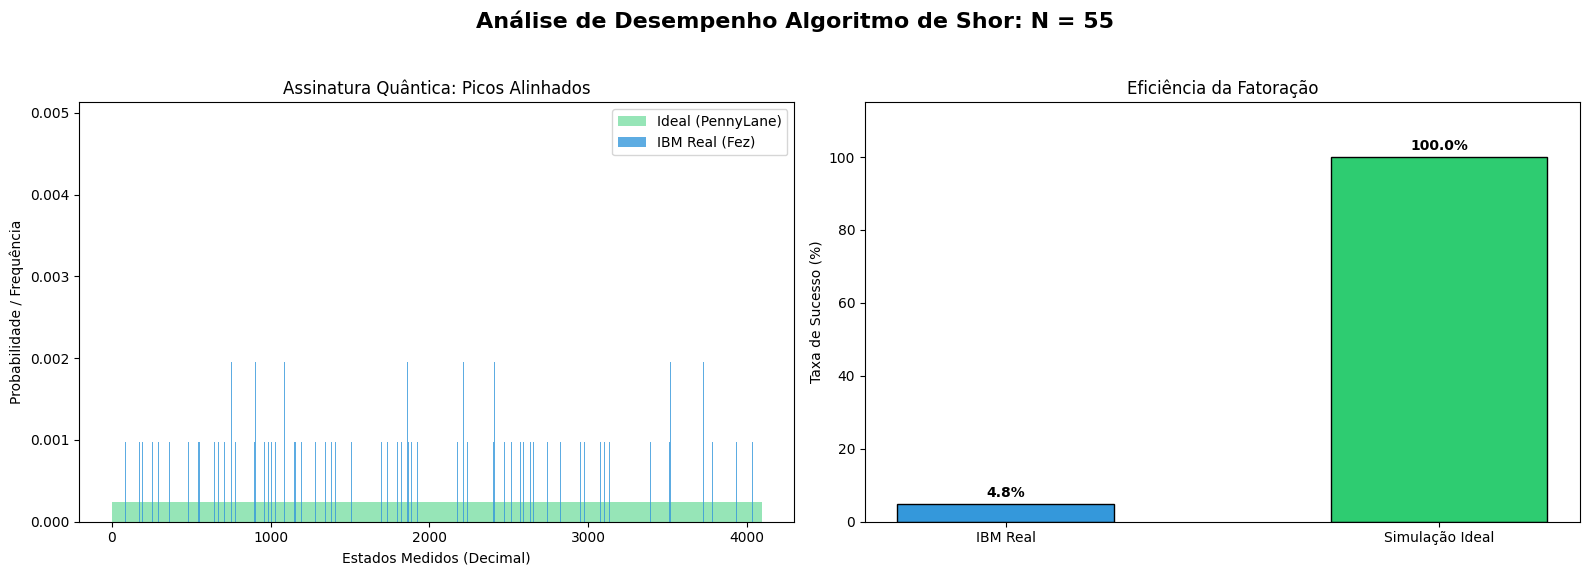

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math DE SUCESSO CORRIGIDA AQUI ---
        for bits, freq in counts_ibm.items():
            decimal = int(bits, 2)
            if decimal == 0: continue
            fase = decimal / (2**m)
            r_calc = Fraction(fase).limit_denominator(N).denominator
            
            # Agora aceita tanto o período exato quanto os seus múltiplos/fatores válidos
            if r_calc > 1 and r_alvo % r_calc == 0: 
                acertos += freq
        # ----------------------------------------
        

try:
    with open('dados_semiprimos_shor_ibm_fez.json', 'r') as f:
        resultados_json = json.load(f)
    print("✅ Arquivo 'dados_semiprimos_shor_ibm_fez.json' carregado com sucesso!")
except FileNotFoundError:
    print("❌ ERRO: O arquivo 'dados_semiprimos_shor_ibm_fez.json' não foi encontrado na mesma pasta.")
    resultados_json = {}

COR_IBM = '#3498db'   
COR_IDEAL = '#2ecc71' 

if resultados_json:
    print("🎨 A gerar gráficos alinhados...")

    for str_N, info in resultados_json.items():
        N = int(str_N)
        counts_ibm = info['counts']
        a_usado = info.get('a_usado', 2)
        L = math.ceil(math.log2(N))
        m = 2 * L
        
        
        estados_ibm = np.zeros(2**m)
        total_shots = sum(counts_ibm.values())
        for bits, freq in counts_ibm.items():
            estados_ibm[int(bits, 2)] = freq / total_shots

        
        probs_ideais_alinhadas = np.zeros(2**m)
        try:
            
            qc_qiskit, _, _, _ = criar_circuito_shor_para_N(N)
            qc_qiskit.remove_final_measurements()
            
            dev = qml.device("default.qubit", wires=L+m)
            @qml.qnode(dev)
            def simular():
                qml.from_qiskit(qc_qiskit)()
                return qml.probs(wires=range(m))
            
            probs_ideais_atual = simular()
            
            
            for i, prob in enumerate(probs_ideais_atual):
                if i >= 2**m: break
                bin_str = format(i, f'0{m}b')
                bin_str_invertido = bin_str[::-1]
                idx_correto = int(bin_str_invertido, 2)
                probs_ideais_alinhadas[idx_correto] = prob
                instance="Shor"
        except NameError:
            print(f"⚠️ Aviso para N={N}: A função 'criar_circuito_shor_para_N' não foi rodada nesta sessão. O gráfico verde ficará vazio, mas o azul (IBM) será gerado.")
        except Exception as e:
            print(f"⚠️ N={N}: A simulação ideal foi ignorada (Erro: {e})")

        # Função auxiliar para encontrar o r ideal
        def get_r(a, n):
            for r in range(1, n):
                if pow(a, r, n) == 1: return r
            return None
        
        r_alvo = get_r(a_usado, N)
        acertos = 0
        
        # --- LÓGICA DE SUCESSO CORRIGIDA AQUI ---
        for bits, freq in counts_ibm.items():
            decimal = int(bits, 2)
            if decimal == 0: continue
            fase = decimal / (2**m)
            r_calc = Fraction(fase).limit_denominator(N).denominator
            
            # Agora aceita tanto o período exato quanto os seus múltiplos/fatores válidos
            if r_calc > 1 and r_alvo % r_calc == 0: 
                acertos += freq
        # ----------------------------------------
        
        taxa_ibm = (acertos / total_shots) * 100

        # Geração dos Gráficos
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f"Análise de Desempenho Algoritmo de Shor: N = {N}", fontsize=16, fontweight='bold')

        # Gráfico 1: Histograma
        ax1.bar(range(2**m), probs_ideais_alinhadas, color=COR_IDEAL, alpha=0.5, label='Ideal (PennyLane)', width=1.0)
        ax1.bar(range(2**m), estados_ibm, color=COR_IBM, alpha=0.8, label='IBM Real (Fez)', width=0.5)
        
        ax1.set_title("Assinatura Quântica: Picos Alinhados")
        ax1.set_xlabel("Estados Medidos (Decimal)")
        ax1.set_ylabel("Probabilidade / Frequência")
        ax1.legend()

        
        labels = ['IBM Real', 'Simulação Ideal']
        valores = [taxa_ibm, 100.0]
        
        bars = ax2.bar(labels, valores, color=[COR_IBM, COR_IDEAL], width=0.5, edgecolor='black', linewidth=1)
        ax2.set_title("Eficiência da Fatoração")
        ax2.set_ylabel("Taxa de Sucesso (%)")
        ax2.set_ylim(0, 115)
        
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', 
                     ha='center', fontweight='bold', color='black')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

📈 Extraindo dados para o gráfico de complexidade...
📸 Gráfico de complexidade salvo com sucesso: grafico_complexidade_shor.png


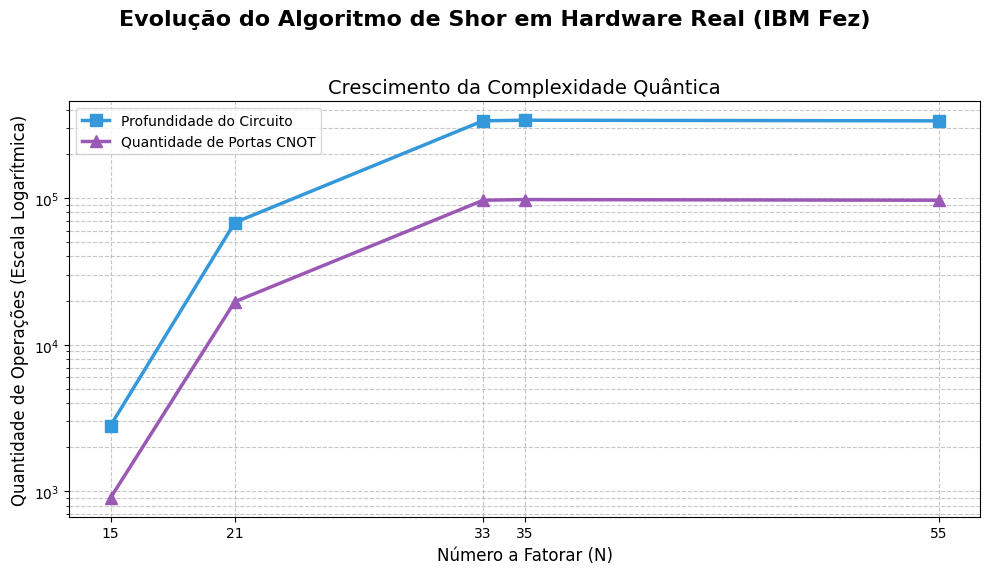

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import math

valores_N = []
profundidades = []
quantidades_cnots = []

print("📈 Extraindo dados para o gráfico de complexidade...")

for str_N, info in resultados_json.items():
    N = int(str_N)
    
    # Extrai apenas os dados de complexidade
    prof = info.get('profundidade', 0)
    cnots = info.get('cnots', 0)
    
    valores_N.append(N)
    profundidades.append(prof)
    quantidades_cnots.append(cnots)

# Ordenar os dados para o gráfico ficar com a linha contínua no eixo X
dados_ordenados = sorted(zip(valores_N, profundidades, quantidades_cnots))
valores_N, profundidades, quantidades_cnots = zip(*dados_ordenados)

# Criar apenas uma figura (sem o subplot duplo)
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Evolução do Algoritmo de Shor em Hardware Real (IBM Fez)", fontsize=16, fontweight='bold')

# Plotar as linhas de Profundidade e CNOTs
ax.plot(valores_N, profundidades, marker='s', markersize=8, color='#3498db', linewidth=2.5, label='Profundidade do Circuito')
ax.plot(valores_N, quantidades_cnots, marker='^', markersize=8, color='#9b59b6', linewidth=2.5, label='Quantidade de Portas CNOT')

# Formatar o gráfico
ax.set_title("Crescimento da Complexidade Quântica", fontsize=14)
ax.set_xlabel("Número a Fatorar (N)", fontsize=12)
ax.set_ylabel("Quantidade de Operações (Escala Logarítmica)", fontsize=12)
ax.set_xticks(valores_N)
ax.set_yscale('log') # Escala logarítmica para evidenciar o crescimento exponencial
ax.grid(True, linestyle='--', alpha=0.7, which='both')
ax.legend()

# Salvar e mostrar
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
nome_arquivo = "grafico_complexidade_shor.png"
plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight', facecolor='white')
print(f"📸 Gráfico de complexidade salvo com sucesso: {nome_arquivo}")
plt.show()